<h1><center>TYPE 1 - TRAINING MODEL WITHOUT REDUCING THE DIMENSION</h1></center>

<h3>STEP 1 - Loading Dataset</h3>

In [3]:
import pandas as pd

data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')

X = data.drop("Encoded_Label", axis=1)
y = data["Encoded_Label"]

print("Dataset Shape: ", data.shape)

Dataset Shape:  (2520751, 81)


<h3>STEP 2 - Scaling</h3>

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_attention\scaler_attention.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 3 - Train/Val/Test SPlit</h3>

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

<h3>STEP 4 - Class Weights (Clamp Weights)</h3>

In [6]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)


class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights
class_weights_dict = {
    k: min(v, 30)
    for k, v in class_weights_dict.items()
}

print(class_weights_dict)

{0: np.float64(0.17188427992709365), 1: 30, 2: 30, 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 30}


<h3>STEP 5 - Reshape for LSTM based on Attention Mechanisms</h3>

In [7]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

<h3>STEP 6 - Create Attention Layer</h3>

In [8]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class Attention(Layer):

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )

    def call(self, inputs):
        score = K.tanh(K.dot(inputs, self.W))
        weights = K.softmax(score, axis=1)
        context = inputs * weights
        context = K.sum(context, axis=1)
        return context

<h3>STEP 7 - Build BiLSTM + Attention Model</h3>

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense, Input
from tensorflow.keras.models import Model

inputs = Input(shape=(78, 1))

x = Bidirectional(LSTM(64, return_sequences=True))(inputs)

x = Attention()(x)

x = Dense(64, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 78, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,631 (166.53 KB)

 Trainable params: 42,631 (166.53 KB)

 Non-trainable params: 0 (0.00 B)

<h3>STEP 8 - Callbacks</h3>

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

<h3>STEP 9 - Train Model</h3>

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 530s 305ms/step - accuracy: 0.6578 - loss: 0.6169 - val_accuracy: 0.8342 - val_loss: 0.5075 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 519s 301ms/step - accuracy: 0.8574 - loss: 0.2760 - val_accuracy: 0.8968 - val_loss: 0.3372 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 520s 301ms/step - accuracy: 0.8938 - loss: 0.1535 - val_accuracy: 0.9147 - val_loss: 0.2817 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 519s 301ms/step - accuracy: 0.9038 - loss: 0.1243 - val_accuracy: 0.8721 - val_loss: 0.2834 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 523s 303ms/step - accuracy: 0.9106 - loss: 0.1027 - val_accuracy: 0.9318 - val_loss: 0.1966 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 525s 304ms/step - accuracy: 0.9153 - loss: 0.0932 - val_accuracy: 0.9303 - val_loss: 0.2221 - learning_rate: 5.0000e-04
Epoch 7/15
1724/1724 ━━━━━━━

<h3>STEP 10 - Evaluate</h3>

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 116s 10ms/step - accuracy: 0.9556 - loss: 0.1328
Test Accuracy: 0.9555661678314209


<h3>Classification Report</h3>

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)

y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step
              precision    recall  f1-score   support

           0     0.9993    0.9476    0.9727    314259
           1     0.0462    0.8733    0.0877       292
           2     0.7521    0.9854    0.8531      1373
           3     0.9150    0.9986    0.9550     19202
           4     0.9241    0.9929    0.9573     29062
           5     0.7165    0.9976    0.8340     13604
           6     0.1870    0.9657    0.3133       321

    accuracy                         0.9556    378113
   macro avg     0.6486    0.9659    0.7104    378113
weighted avg     0.9767    0.9556    0.9640    378113



<h3>Confusion Matrix</h3>

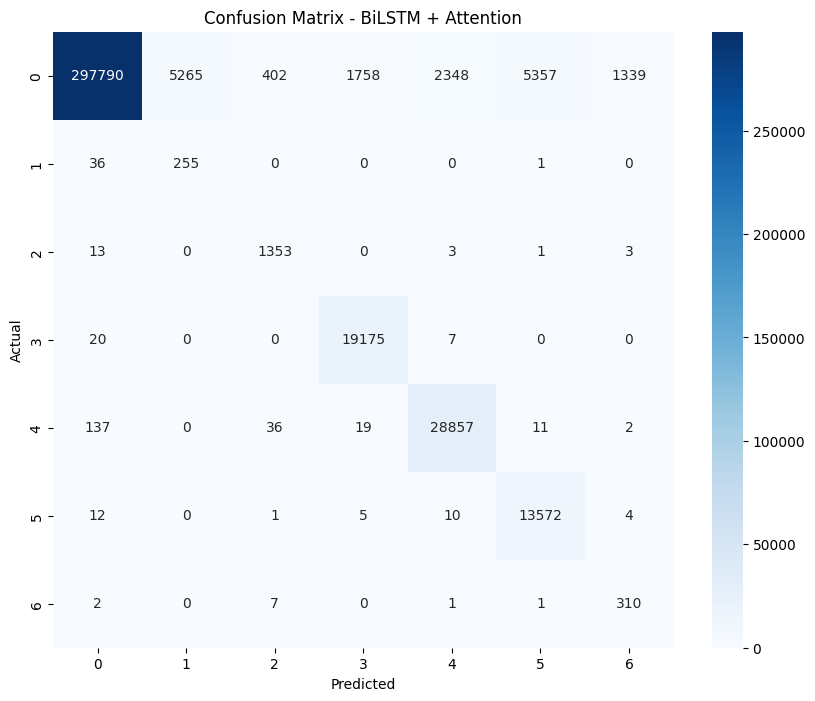

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

plt.title("Confusion Matrix - BiLSTM + Attention")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

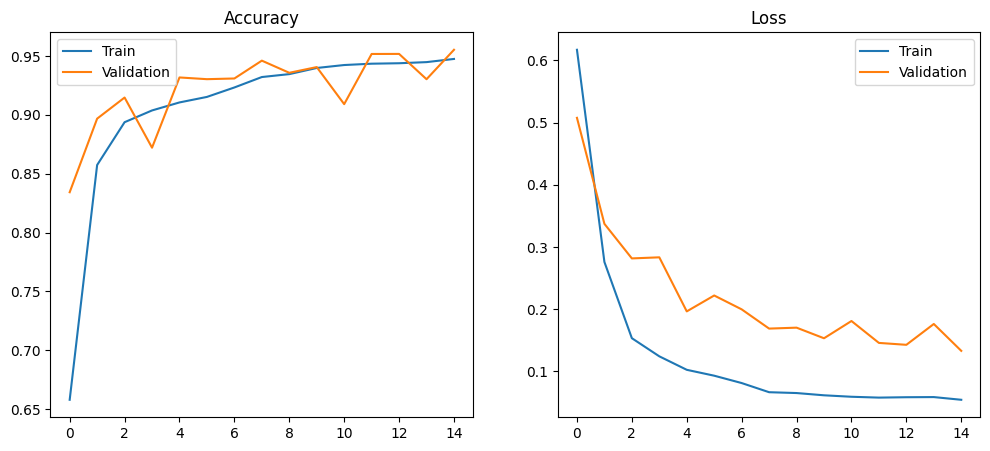

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [16]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_attention\bilstm_attention_model.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_attention\bilstm_attention_model.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.


<h1><center>TYPE 2 - TRAINING MODEL WITH SELECTED TOP 35 FEATURES</h1></center>

In [17]:
import pandas as pd

data_top_sec = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_04\cicids2017_selected_top_features.csv')

X = data_top_sec.drop("Encoded_Label", axis=1)
y = data_top_sec["Encoded_Label"]

print("Dataset Shape: ", data_top_sec.shape)

Dataset Shape:  (2520751, 36)


In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_attention\bilstm_scaler_top_sec.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1764525, 35)
Validation: (378113, 35)
Test: (378113, 35)


In [20]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights to prevent instability
class_weights_dict = {
    k: min(v, 50)
    for k, v in class_weights_dict.items()
}

print("Final Class Weights:")
print(class_weights_dict)

Final Class Weights:
{0: np.float64(0.17188427992709365), 1: 50, 2: np.float64(39.3559718969555), 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 50}


In [21]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaped Train:", X_train.shape)

Reshaped Train: (1764525, 35, 1)


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(35,1)),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,503 (166.03 KB)

 Trainable params: 42,503 (166.03 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 173s 99ms/step - accuracy: 0.7598 - loss: 0.4653 - val_accuracy: 0.8632 - val_loss: 0.4044 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 171s 99ms/step - accuracy: 0.8468 - loss: 0.2599 - val_accuracy: 0.8552 - val_loss: 0.4302 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 12920s 7s/step - accuracy: 0.8645 - loss: 0.2192 - val_accuracy: 0.8971 - val_loss: 0.3151 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 165s 96ms/step - accuracy: 0.8767 - loss: 0.1886 - val_accuracy: 0.8910 - val_loss: 0.3128 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 171s 99ms/step - accuracy: 0.8829 - loss: 0.1874 - val_accuracy: 0.9152 - val_loss: 0.2393 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 168s 97ms/step - accuracy: 0.8926 - loss: 0.1657 - val_accuracy: 0.9201 - val_loss: 0.2392 - learning_rate: 5.0000e-04
Epoch 7/15
1723/1724 ━━━━━━━━━━━━━

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 84s 7ms/step - accuracy: 0.9192 - loss: 0.2250
Test Accuracy: 0.9191696643829346


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step
              precision    recall  f1-score   support

           0     0.9984    0.9051    0.9495    314259
           1     0.0328    0.8562    0.0632       292
           2     0.4444    0.9636    0.6083      1373
           3     0.7887    0.9980    0.8811     19202
           4     0.7862    0.9820    0.8733     29062
           5     0.6870    0.9944    0.8126     13604
           6     0.1310    0.9470    0.2301       321

    accuracy                         0.9192    378113
   macro avg     0.5526    0.9495    0.6311    378113
weighted avg     0.9567    0.9192    0.9327    378113



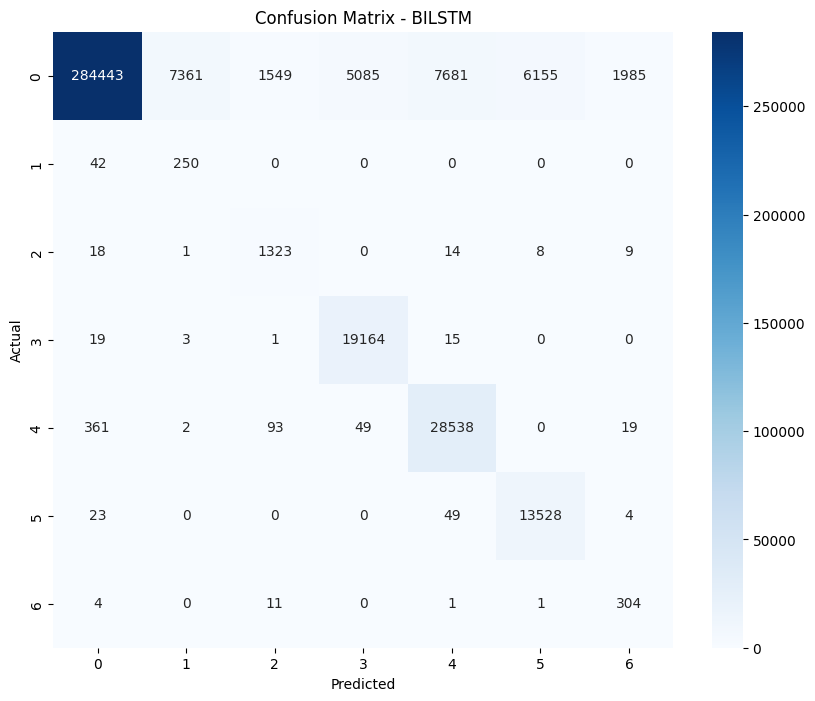

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - BILSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_attention\bilstm_model.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm_attention\bilstm_model.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.
